# Лабораторная работа №5.
# Анимация качения треугольника Рело по квадрату

*Коровацкий Александр Сергеевич, 19.04.2025*

## Задание 5.1. Начальное положение треугольника Рело и квадрата

**Треугольник Рело** представляет собой область пересечения трех кругов радиуса
с центрами в вершинах равностороннего треугольника с длиной стороны .
Так как треугольник Рело является фигурой постоянной ширины, то его можно
вписать в квадрат с длиной стороны, равной ширине треугольника Рело таким
образом, что треугольник Рело будет касаться всех сторон квадрата. Это связано с
тем, что противоположные стороны квадрата, расстояние между которыми равно ,
располагаются на опорных прямых к треугольнику Рело

**Поступательное движение фигуры** – это движение, при котором траектории
движения всех точек фигуры одинаковы.

**Вращательное движение фигуры** – это движение, при котором траектории
движения точек фигуры представляют собой окружности (или дуги окружностей) с
центрами, лежащими в одной точке.

**Качение треугольника Рело по квадрату** – это вращательное движение
треугольника Рело относительно своего центра с дополнительным поступательным
движением центра треугольника по траектории, близкой к окружности, чтобы
обеспечить касание всех сторон квадрата при движении треугольника Рело.
Качение треугольника Рело происходит за счет его одновременного
поступательного и вращательного движения.

Полагаем, что при качении по квадрату против часовой стрелки центр треугольника
Рело совершает поступательное движение по окружности против часовой стрелки
с центром окружности, расположенным в начале координат. Радиус окружности
для поступательного движения является неизвестным и будет вычислен в Задании
5.1.

Одновременно с поступательным движением треугольник Рело совершает
вращательное движение по часовой стрелке. Поступательное и вращательное
движения согласованы таким образом, что поступательное движение по всей
окружности соответствует вращательному движению треугольника Рело на угол $\frac{2\pi}{3}$.

In [2]:
import math
import numpy as np
import relo
import matplotlib.pyplot as plt

Определим исходные данные для построения треугольника Рело:

In [4]:
numbOfVert = 3
center = np.array([0., 0.])
triangleWidth = 10.
numbOfPoint = 100

Для построения матрицы relo_matrix координат точек-границ треугольника
Рело используем функцию regular_polygon_Relo(n, center, r, N) из модуля
relo , созданного в Лабораторной работе 4

In [10]:
reloMatrix = relo.regularPolygonReloFunc(numbOfVert, center, triangleWidth, numbOfPoint)

Длина стороны квадрата равна ширине треугольника Рело , центр квадрата
располагаем в начале координат.

In [12]:
angleList = np.arange(0, 2 * np.pi, np.pi / 2)
square = center + triangleWidth * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), np.sign(np.sin(angleList + np.pi / 4))])
square = np.vstack([square, square[0]])

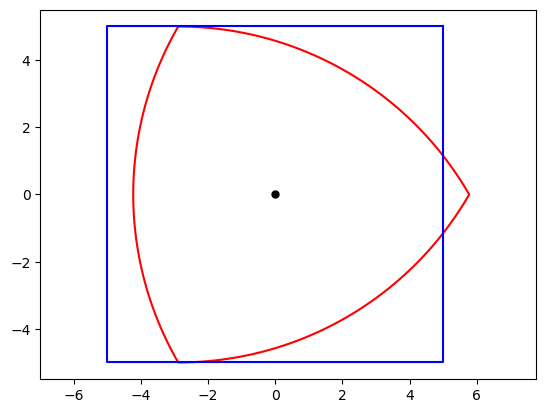

In [14]:
plt.plot(reloMatrix[:,0], reloMatrix[:,1], 'r-')
plt.plot(square[:,0], square[:,1], 'b-')
plt.plot(center[0], center[1], 'k.', markersize = 10)

plt.axis('equal')
plt.show()

**Рассмотрим правильный треугольник Рело**. Можно заметить, что его вершины находятся на окружности радиуса $R$. Квадрат же был построен исходя из значения **половины ширины правильного треугольника Рело $\frac{r}{2}$**. Поэтому, чтобы определить сдвиг $shift$, на который нужно переместить треугольник Рело, чтобы он оказался вписан в квадрат, нужно найти разность между $R$ и $\frac{r}{2}$.
<b>$$\text{shift} = R - \frac{r}{2}$$
Формула для нахождения радиуса описанной вокруг правильного треугольника Рело равна:
$$R = \frac{r}{2 \sin(\frac{\pi}{n})}$$

Подставив в $\text{shift} = R - \frac{r}{2}$ получим:
$$\text{shift} = \frac{r}{2 \sin(\frac{\pi}{n})} - \frac{r}{2} = \frac{r}{2}(\frac{1}{\sin(\frac{\pi}{n})} - 1)$$

In [20]:
shift = np.array([triangleWidth * 0.5 * (1 / np.sin(np.pi / numbOfVert) - 1), 0])
reloMatrixShifted = reloMatrix - shift
center -= shift

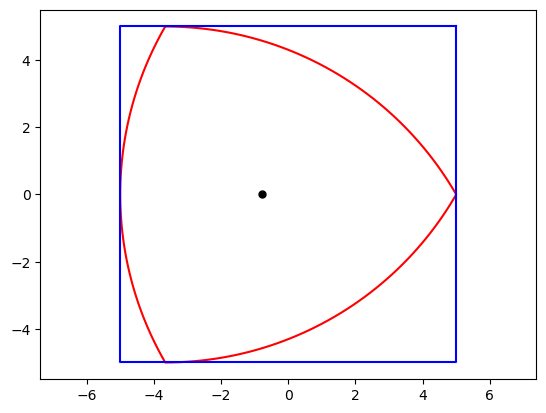

In [22]:
plt.plot(reloMatrixShifted[:,0], reloMatrixShifted[:,1], 'r-')
plt.plot(square[:,0], square[:,1], 'b-')
plt.plot(center[0], center[1], 'k.', markersize = 10)

plt.axis('equal')
plt.show()

## Задание 5.2. Анимация поступательного движения треугольника Рело по окружности 

Зададим количество кадров анимации N_frames , необходимое для
поступательного движения треугольника с полным обходом окружности

In [26]:
nFrames = 100

Создадим матрицу center_frame из N_frames строк и двух столбцов для
описания координат точек окружности, необходимой для реализации
поступательного движения, с центром в начале координат и радиусом shift[0]
при обходе окружности против часовой стрелки от до . В первом столбце
матрицы расположены -координаты точек, во втором столбце -- координаты.

In [29]:
tCenter = np.linspace(-np.pi, np.pi, nFrames)
centerFrame = shift[0] * np.transpose([np.cos(tCenter), np.sin(tCenter)])

Изобразим первый кадр анимации.

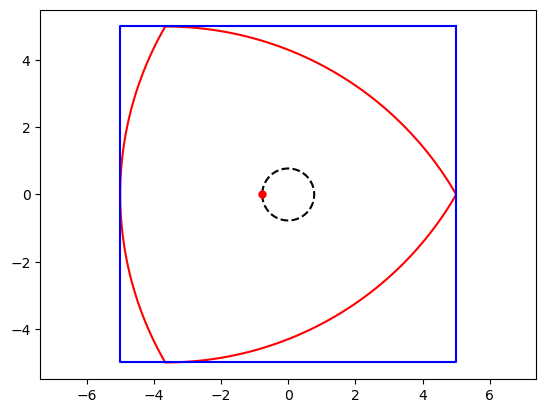

In [32]:
frame = 0
reloMatrixShifted = reloMatrix + centerFrame[frame]
plt.figure()

plt.plot(reloMatrixShifted[:,0], reloMatrixShifted[:,1], 'r-')
plt.plot(square[:,0], square[:,1], 'b-')
plt.plot(centerFrame[:,0], centerFrame[:,1], 'k--')
plt.plot(centerFrame[frame, 0], centerFrame[frame, 1], 'r.', markersize=10)

plt.axis('equal');

### Пользовательская функция drawFrame 

In [39]:
def drawFrame(triangleWidth: float = 10., 
              nFrames: int = 100, 
              frame: int = 0) -> None:
    
    """
    Изображает кадр с номером frame при поступательном движении центра треугольника 
    Рело по окружности против часовой стрелки.

    Параметры:
        triangleWidth (float): Ширина (по умолчанию 10);
        nFrames (int): Число кадров (по умолчанию 100);
        frame (int): Номер текущего кадра (по умолчанию 0);
        center (np.ndarray): Центр (по умолчанию np.array([0, 0]));
        numbOfPoint (int): Число точек на дуге (по умолчанию 100).

    Возвращает:
        Функция не возвращает объекты.
    """

    numbOfVert = 3
    center = np.array([0., 0.]) 
    numbOfPoint = 100

    reloMatrix = relo.regularPolygonReloFunc(numbOfVert, center, triangleWidth, numbOfPoint)

    angleList = np.arange(0, 2 * np.pi, np.pi / 2)
    square = center + triangleWidth * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                          np.sign(np.sin(angleList + np.pi / 4))])
    square = np.vstack([square, square[0]])

    shift = np.array([triangleWidth * 0.5 * (1 / np.sin(np.pi / numbOfVert) - 1), 0])
    tCenter = np.linspace(-np.pi, np.pi, nFrames)
    centerFrame = shift[0] * np.transpose([np.cos(tCenter), np.sin(tCenter)])

    reloMatrixShifted = reloMatrix + centerFrame[frame]
       
    plt.plot(reloMatrixShifted[:,0], reloMatrixShifted[:,1], 'r-')
    plt.plot(square[:,0], square[:,1], 'b-')
    plt.plot(centerFrame[:,0], centerFrame[:,1], 'k--')
    plt.plot(centerFrame[frame, 0], centerFrame[frame, 1], 'r.', markersize=10)

    plt.axis('equal')

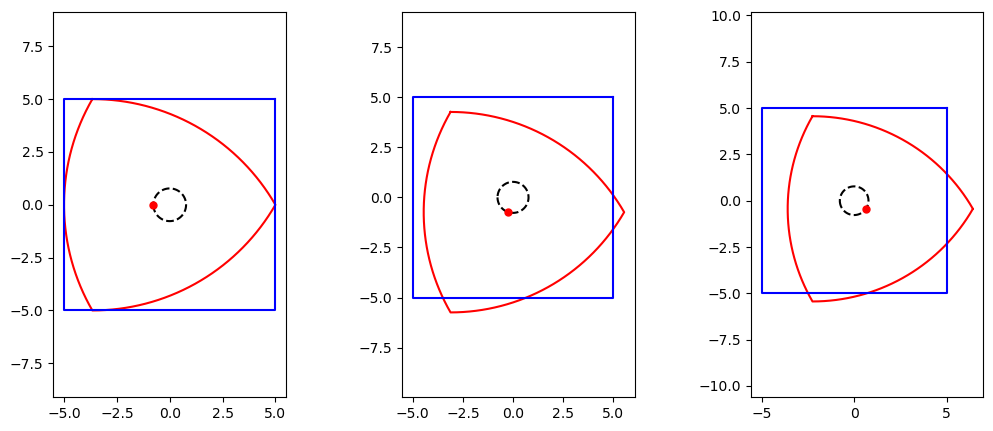

In [41]:
plt.figure(figsize = (12, 5))
plt.subplots_adjust(wspace = 0.5)

nFrames = 100
plt.subplot(1,3,1)
drawFrame(triangleWidth = triangleWidth, nFrames = nFrames)
plt.subplot(1,3,2)
drawFrame(triangleWidth = triangleWidth, nFrames = nFrames, frame = 20)
plt.subplot(1,3,3)
drawFrame(triangleWidth = triangleWidth, nFrames = nFrames, frame = 40)

### Анимации поступательного движения треугольника Рело

In [43]:
from matplotlib.animation import FuncAnimation

%matplotlib widget

AttributeError: module 'relo' has no attribute 'regularPolygonRelo'

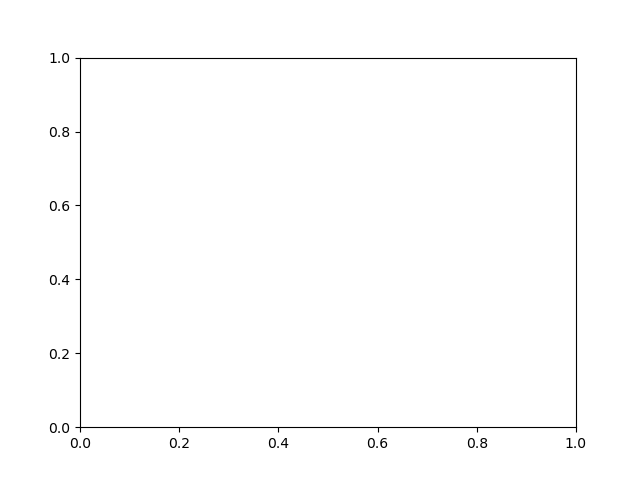

In [45]:
fig1 = plt.figure()
ax1 = plt.axes()


def init():
    global line, reloTriangle, reloMatrix, centerFrame

    numbOfVert, numbOfPoint = 3, 100
    triangleWidth, nFrames = 10., 100
    center = np.array([0., 0.]) 

    reloMatrix = relo.regularPolygonRelo(numbOfVert, center, triangleWidth, numbOfPoint)

    angleList = np.arange(0, 2 * np.pi, np.pi / 2)
    square = center + triangleWidth * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                          np.sign(np.sin(angleList + np.pi / 4))])
    square = np.vstack([square, square[0]])

    shift = np.array([triangleWidth * 0.5 * (1 / np.sin(np.pi / numbOfVert) - 1), 0])
    tCenter = np.linspace(-np.pi, np.pi, nFrames)
    centerFrame = shift[0] * np.transpose([np.cos(tCenter), np.sin(tCenter)])

    ax1.clear()
    
    reloTriangle, = ax1.plot(reloMatrix[:, 0], reloMatrix[:, 1], 'r-', markersize = 15)
    ax1.plot(square[:, 0], square[:, 1], 'b-')
    ax1.plot(centerFrame[:, 0], centerFrame[:, 1], 'k--')
    line, = ax1.plot([], [],'r.', markersize = 10)
    
    ax1.axis('equal')
    

def atFrame(frame):
    newReloMatrix = reloMatrix + centerFrame[frame]
    
    reloTriangle.set_data(newReloMatrix[:, 0], newReloMatrix[:, 1])
    line.set_data([centerFrame[frame, 0]], [centerFrame[frame, 1]])


init()

FuncAnimation(fig1, atFrame, frames = len(centerFrame), init_func = init, repeat = False, interval = 20)

In [47]:
plt.close('all')

## Задание 5.3. Анимация качения треугольника Рело

Дополнительно к поступательному движению треугольника Рело против часовой стрелки добавим вращательное движение по часовой стрелке на угол $\theta$. При этом будем учитывать, что полный оборот центра треугольника на угол $2\pi$ соответствует вращению треугольника Рело на угол $\frac{2\pi}{3}$


Определим пользовательскую функцию rotate_matrix(theta) для создания
матрицы поворота по часовой стрелке на угол theta с применением
синтаксиса lambda -функций


In [49]:
rotationMatrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
                                         [-np.sin(theta), np.cos(theta)]])

rotationMatrix(np.pi)

array([[-1.0000000e+00,  1.2246468e-16],
       [-1.2246468e-16, -1.0000000e+00]])

In [51]:
theta = np.pi / 3
matrix = rotationMatrix(theta)

reloMatrixRotated = np.array([np.dot(matrix, row) for row in reloMatrix])


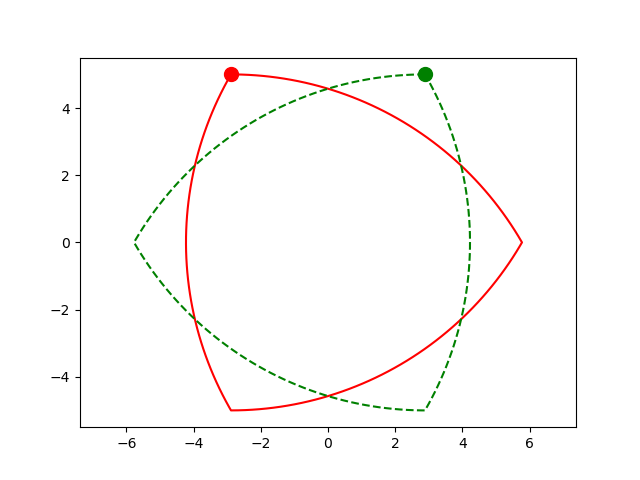

In [53]:
plt.figure()

plt.plot(reloMatrix[:,0], reloMatrix[:,1], 'r-')
plt.plot(reloMatrix[0, 0], reloMatrix[0, 1], 'r.', markersize=20)
plt.plot(reloMatrixRotated[:, 0], reloMatrixRotated[:, 1], 'g--')
plt.plot(reloMatrixRotated[0, 0], reloMatrixRotated[0, 1], 'g.', markersize=20)

plt.axis('equal');

Определим массив theta со значениями угла поворота при вращательном
движении, согласованный с полным оборотом центра треугольника Рело за
N_frames кадров.

In [55]:
theta = np.linspace(0, 2 * np.pi / 3, nFrames)

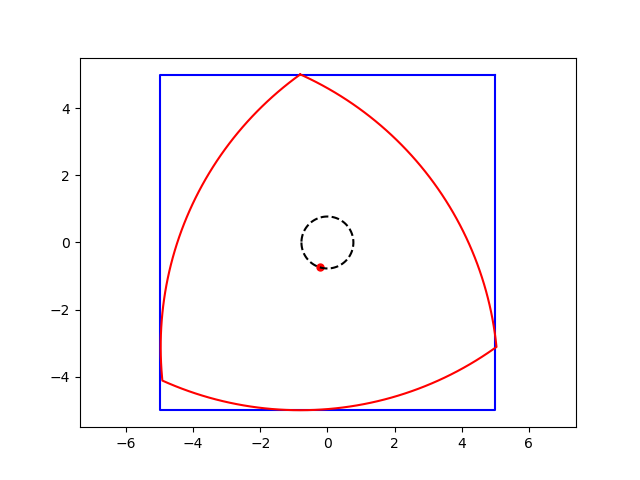

In [57]:
frame = 20

matrix = rotationMatrix(theta[frame])
reloMatrixChanged = (np.array([np.dot(matrix,row) for row in reloMatrix]) 
                     + centerFrame[frame])

plt.figure()
plt.plot(square[:,0],square[:,1],'b-')
plt.plot(reloMatrixChanged[:,0],reloMatrixChanged[:,1],'r-')
plt.plot(centerFrame[frame,0],centerFrame[frame,1],'r.',markersize=10)
plt.plot(centerFrame[:,0],centerFrame[:,1],'k--')
plt.axis('equal');

### Измененная функция drawFrame

In [59]:
def drawFrame(triangleWidth: float = 10., 
              nFrames: int = 100, 
              frame: int = 0) -> None:
    
    """
    Изображает кадр с номером frame при качении треугольника Рело по 
    окружности против часовой стрелки.

    Параметры:
        triangleWidth (float): Ширина (по умолчанию 10);
        nFrames (int): Число кадров анимации (по умолчанию 100);
        frame (int): Номер текущего кадра (по умолчанию 0);
        center (np.ndarray): Центр (по умолчанию [0, 0]);
        numbOfPoint (int): Число точек на дуге (по умолчанию 100).

    Возвращает:
        Функция не возвращает объекты.
    """

    numbOfVert, numbOfPoint = 3, 100
    center = np.array([0., 0.]) 

    rotationMatrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
                                         [-np.sin(theta), np.cos(theta)]])

    reloMatrix = relo.regularPolygonRelo(numbOfVert, center, triangleWidth, numbOfPoint)

    angleList = np.arange(0, 2 * np.pi, np.pi / 2)
    square = center + triangleWidth * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                          np.sign(np.sin(angleList + np.pi / 4))])
    square = np.vstack([square, square[0]])

    shift = np.array([triangleWidth * 0.5 * (1 / np.sin(np.pi / numbOfVert) - 1), 0])
    tCenter = np.linspace(-np.pi, np.pi, nFrames)
    centerFrame = shift[0] * np.transpose([np.cos(tCenter), np.sin(tCenter)])

    theta = np.linspace(0, 2 * np.pi / 3, nFrames)
    matrix = rotationMatrix(theta[frame])
    reloMatrixChanged = (np.array([np.dot(matrix,row) for row in reloMatrix]) 
                         + centerFrame[frame])
    
    plt.plot(reloMatrixChanged[:,0], reloMatrixChanged[:,1], 'r-')    
    plt.plot(square[:,0], square[:,1], 'b-')
    plt.plot(centerFrame[frame, 0], centerFrame[frame, 1], 'r.', markersize=10)
    plt.plot(centerFrame[:,0], centerFrame[:,1], 'k--')

    plt.axis('equal')

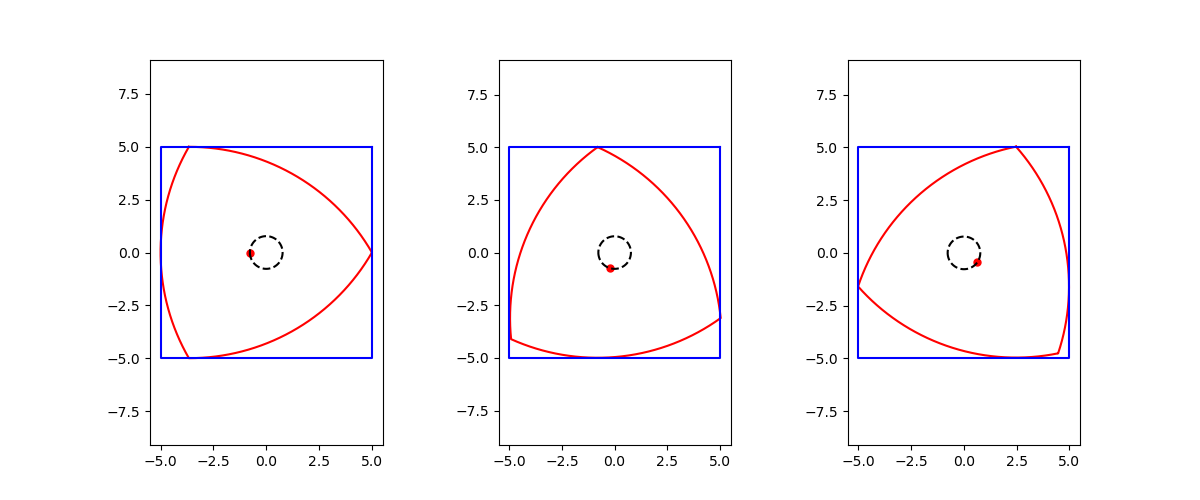

In [22]:
plt.figure(figsize = (12, 5))
plt.subplots_adjust(wspace = 0.5)

plt.subplot(1,3,1)
drawFrame(triangleWidth = triangleWidth, nFrames = nFrames)
plt.subplot(1,3,2)
drawFrame(triangleWidth = triangleWidth, nFrames = nFrames, frame = 20)
plt.subplot(1,3,3)
drawFrame(triangleWidth = triangleWidth, nFrames = nFrames, frame = 40)


### Анимация качения треугольника Рело против часовой стрелки

AttributeError: module 'relo' has no attribute 'regularPolygonRelo'

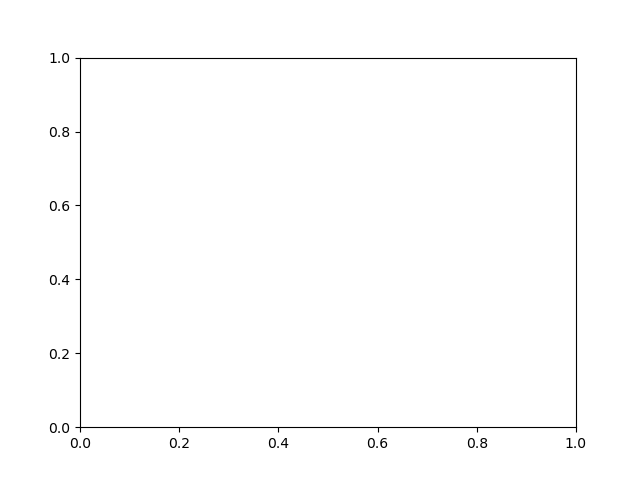

In [61]:
fig1 = plt.figure()
ax1 = plt.axes()


def init():
    global line, reloTriangle, reloMatrix, centerFrame, rotationMatrix, theta

    numbOfVert, numbOfPoint = 3, 100
    triangleWidth, nFrames = 10., 100
    center = np.array([0., 0.]) 

    rotationMatrix = lambda theta: np.array([[np.cos(theta), np.sin(theta)],
                                         [-np.sin(theta), np.cos(theta)]])

    reloMatrix = relo.regularPolygonRelo(numbOfVert, center, triangleWidth, numbOfPoint)

    angleList = np.arange(0, 2 * np.pi, np.pi / 2)
    square = center + triangleWidth * 0.5 * np.transpose([np.sign(np.cos(angleList + np.pi / 4)), 
                                                          np.sign(np.sin(angleList + np.pi / 4))])
    square = np.vstack([square, square[0]])

    shift = np.array([triangleWidth * 0.5 * (1 / np.sin(np.pi / numbOfVert) - 1), 0])
    tCenter = np.linspace(-np.pi, np.pi, nFrames)
    centerFrame = shift[0] * np.transpose([np.cos(tCenter), np.sin(tCenter)])

    theta = np.linspace(0, 2 * np.pi / 3, nFrames)
    matrix = rotationMatrix(theta[0])
    reloMatrixChanged = (np.array([np.dot(matrix,row) for row in reloMatrix]) 
                         + centerFrame[0])

    ax1.clear()
    
    reloTriangle, = ax1.plot(reloMatrixChanged[:, 0], reloMatrixChanged[:, 1], 'r-', markersize = 15)
    ax1.plot(square[:, 0], square[:, 1], 'b-')
    ax1.plot(centerFrame[:, 0], centerFrame[:, 1], 'k--')
    line, = ax1.plot([], [],'r.', markersize = 10)
    
    ax1.axis('equal')
    

def atFrame(frame):
    matrix = rotationMatrix(theta[frame])
    reloMatrixChanged = (np.array([np.dot(matrix,row) for row in reloMatrix]) 
                         + centerFrame[frame])
    
    reloTriangle.set_data(reloMatrixChanged[:, 0], reloMatrixChanged[:, 1])
    line.set_data([centerFrame[frame, 0]], [centerFrame[frame, 1]])

init()

FuncAnimation(fig1, atFrame, frames = len(centerFrame), init_func = init, repeat = False, interval = 20)

In [63]:
plt.close('all')